# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes.

## Prerequisites

The following Python modules are required to execute the cells of this notebook.

In [340]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

The following constants assume that the "All Classes" version of the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [341]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

## Exploratory Data Analysis

### Data Loading and Inspection

Here, we load the ground truth labels associated with the training, validation, and testing sets into memory and analyze their data.

In [342]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

display(training_metadata.head())
display(validation_metadata.head())
display(testing_metadata.head())

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


As shown by the tables above, there are a large number of attributes to account for. The ID attribute identifies a unique fundus image from either the training, validation, or testing sets. The Disease_Risk attribute flags each fundus image as having diseases or not. The remaining 45 attributes flag each fundus image as having specific kinds of diseases, but they are not necessarily mutually exclusive with one another. This introduces an interesting wrinkle in our classification problem, as we have fundus images that can contain multiple diseases.

### Feature-Level Analysis

Now, let's find the statistical frequency and proportion of each label in the dataset. The dataset has already been cleaned of any invalid data, so we can start calculating the statistics immediately. While we are at it, we will replace the Disease_Risk label with the Healthy label to capture statistics for the healthy class. Since Disease_Risk marks which images have eye diseases, it makes sense to invert the values to mark images with no eye diseases.

In [343]:
# Create modified metadata table.
metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)
metadata.rename(columns={'Disease_Risk': 'Healthy'}, inplace=True)
metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

# Create the statistics dataframe.
statistics = pd.DataFrame(data={
    'Label' : [*metadata.columns[1:]],
    'Frequency' : [0] * 46,
    'Proportion' : [0.0] * 46
})

# Compute the frequency and proportion of each label.
for i, label in enumerate(statistics['Label']):
    frequency = metadata[label].sum()
    statistics.at[i, 'Frequency'] = frequency
    statistics.at[i, 'Proportion'] = frequency / 3200

display(statistics)

,Label,Frequency,Proportion
0,Healthy,669,0.209063
1,DR,632,0.197500
2,ARMD,169,0.052812
3,MH,523,0.163438
4,DN,230,0.071875
5,MYA,167,0.052187
6,BRVO,119,0.037187
7,TSLN,304,0.095000
8,ERM,26,0.008125
9,LS,79,0.024688


Looking at the statistics, some diseases appear to be far more rare than others. Let's draw a histogram to get a better look of the class balance.

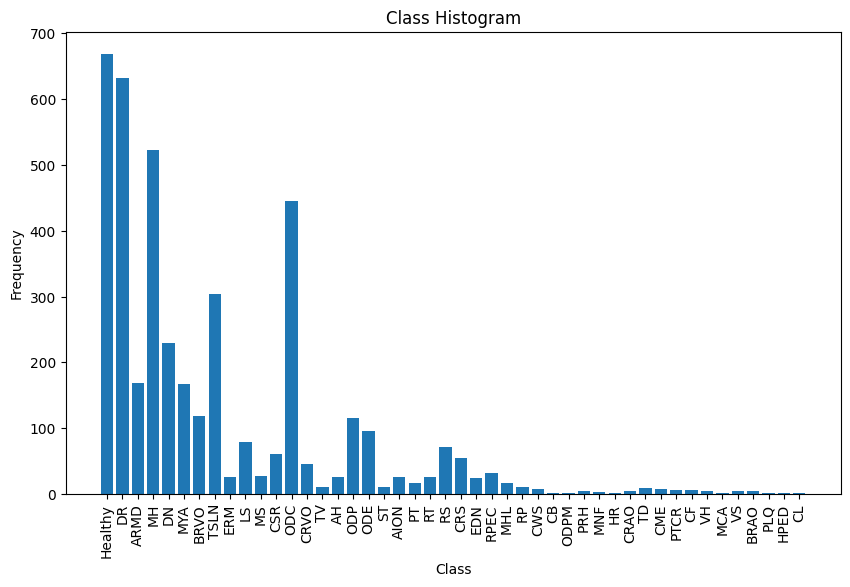

In [344]:
plt.figure(figsize=(10, 6))
plt.title('Class Histogram')
plt.xlabel('Class')
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.bar(statistics['Label'], statistics['Frequency'])
plt.show()

As shown by the histogram, the Healthy, DR, MH, TSLN, and ODC classes dominate the dataset, introducing a class imbalance. Furthermore, there are several classes like CWS, CB, and PRH whose frequencies are in the single digits. This imbalance can cause our models to become biased towards the more frequent class examples. If left unaddressed, this bias can hurt our models' performance on less frequent class examples. 

One other thing we should look out for is the correlation between classes. Let's check it out.

In [345]:
correlations = metadata.drop(['ID'], axis=1).corr()
display(correlations)

,Healthy,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,LS,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
Healthy,1.000000,-0.255052,-0.121400,-0.227245,-0.143071,-0.120639,-0.101040,-0.166573,-0.046532,-0.081796,...,-0.024072,-0.022283,-0.022283,-0.018188,-0.009090,-0.018188,-0.018188,-0.012857,-0.009090,-0.012857
DR,-0.255052,1.000000,-0.117142,-0.140729,-0.128936,-0.095232,-0.085051,-0.018846,-0.027412,0.214474,...,-0.023228,-0.021502,-0.021502,0.004665,0.035640,-0.017550,-0.017550,-0.012406,-0.008771,-0.012406
ARMD,-0.121400,-0.117142,1.000000,-0.077920,-0.033253,0.195884,-0.039022,0.118867,-0.021371,-0.037568,...,-0.011056,-0.010234,-0.010234,-0.008354,-0.004175,-0.008354,-0.008354,-0.005905,-0.004175,-0.005905
MH,-0.227245,-0.140729,-0.077920,1.000000,-0.083736,-0.035317,-0.060069,0.075848,-0.040005,-0.070322,...,-0.020696,-0.019157,-0.019157,0.056120,-0.007815,-0.015637,0.008282,-0.011054,-0.007815,-0.011054
DN,-0.143071,-0.128936,-0.033253,-0.083736,1.000000,-0.048979,-0.048296,0.008872,-0.011709,-0.020882,...,-0.013030,0.015907,-0.012061,-0.009845,-0.004920,-0.009845,-0.009845,-0.006959,-0.004920,-0.006959
MYA,-0.120639,-0.095232,0.195884,-0.035317,-0.048979,1.000000,-0.031264,-0.076026,-0.021238,-0.028278,...,-0.010987,-0.010170,-0.010170,-0.008301,-0.004149,-0.008301,-0.008301,-0.005868,-0.004149,-0.005868
BRVO,-0.101040,-0.085051,-0.039022,-0.060069,-0.048296,-0.031264,1.000000,-0.018615,-0.017787,-0.009981,...,-0.009202,-0.008518,-0.008518,0.039788,-0.003475,0.039788,-0.006953,-0.004915,-0.003475,0.061166
TSLN,-0.166573,-0.018846,0.118867,0.075848,0.008872,-0.076026,-0.018615,1.000000,-0.005580,-0.003469,...,-0.015170,0.010593,-0.014043,-0.011462,0.054570,-0.011462,-0.011462,-0.008102,-0.005728,0.034542
ERM,-0.046532,-0.027412,-0.021371,-0.040005,-0.011709,-0.021238,-0.017787,-0.005580,1.000000,0.030468,...,-0.004238,-0.003923,-0.003923,-0.003202,-0.001600,-0.003202,-0.003202,-0.002263,-0.001600,-0.002263
LS,-0.081796,0.214474,-0.037568,-0.070322,-0.020882,-0.028278,-0.009981,-0.003469,0.030468,1.000000,...,-0.007449,-0.006896,-0.006896,-0.005629,-0.002813,-0.005629,-0.005629,-0.003979,-0.002813,-0.003979


There appears to be some classes that correlate with one another. Let's draw a heatmap to get a better look.

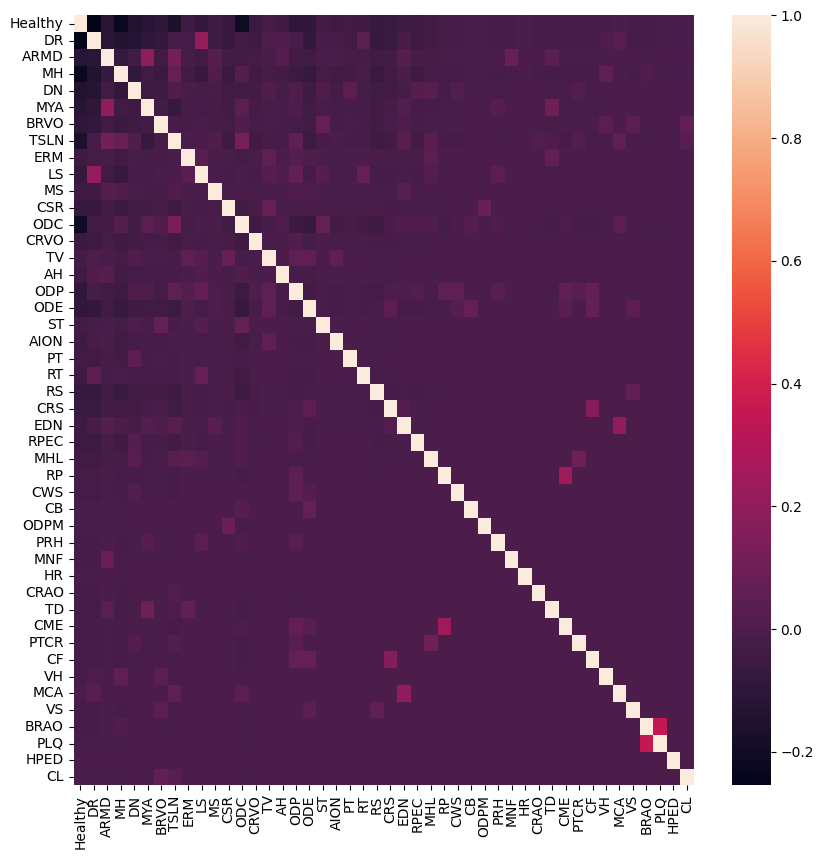

In [346]:
plt.figure(figsize=(10, 10))
sns.heatmap(correlations, xticklabels=True, yticklabels=True)
plt.show()

The correlation is not too bad. However, there are pairs of classes like LS and DR that have positive correlations with one another, which can potentially trip up our models when they are seen separate from each other. Similarly, classes with negative correlations have the potential to trip up our models when they are seen together.

### Image Example Visualizations

Let's conclude our exploratory data analysis by visualizing some image examples from our dataset.

In [347]:
#TODO: Visualize images from the dataset.